# SyriaTel Customer Churn Prediction - Phase 3 project

**Author:** Angela Mukami K

**Date:** February 2026

---

## Table of Contents

1. [Business Understanding](#business-understanding)
2. [Data Understanding](#data-understanding)
3. [Data Preparation](#data-preparation)
4. [Modeling](#modeling)
5. [Evaluation](#evaluation)
6. [Conclusions and Recommendations](#conclusions-and-recommendations)

---

## 1. Business Understanding <a id='business-understanding'></a>

### Stakeholder
SyriaTel, a telecommunications company

### Business Problem
SyriaTel is experiencing customer churn, which directly impacts revenue and profitability. When customers leave, the company loses not only their recurring revenue but also the investment made in acquiring them. 

### Project Objective
Build a classification model to predict whether a customer will churn (stop doing business with SyriaTel) based on their account information and usage patterns.

### Success Criteria
- Identify key features that predict customer churn
- Build a model with strong predictive performance
- Provide actionable recommendations to reduce churn

### Why Classification?
This is a binary classification problem because our target variable (churn) is categorical:
- Class 0: Customer stays
- Class 1: Customer churns

We need to predict which category a customer falls into, not a numeric value.

---

## 2. Data Understanding <a id='data-understanding'></a>

### 2.1 Import Libraries

In [9]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Machine Learning - Evaluation
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix, 
    classification_report,
    roc_auc_score,
    roc_curve
)

# Model tuning
from sklearn.model_selection import GridSearchCV, cross_val_score

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


### 2.2 Load Data

In [10]:
# Load the dataset
# Update the filename below to match your dataset file name
df = pd.read_csv('syriatel_data.csv')

# Display first few rows
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


### 2.3 Initial Data Exploration

In [11]:
# Dataset shape
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (3333, 21)
Number of rows: 3333
Number of columns: 21


In [12]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [10]:
# Statistical summary
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [11]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

Total missing values: 0


In [12]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


### 2.4 Target Variable Analysis

In [13]:
# we will take 'churn' as the target variable
target_col = 'churn'  

# Check target variable distribution
print("Target variable distribution:")
print(df[target_col].value_counts())
print("\nPercentages:")
print(df[target_col].value_counts(normalize=True) * 100)

Target variable distribution:
churn
False    2850
True      483
Name: count, dtype: int64

Percentages:
churn
False    85.508551
True     14.491449
Name: proportion, dtype: float64


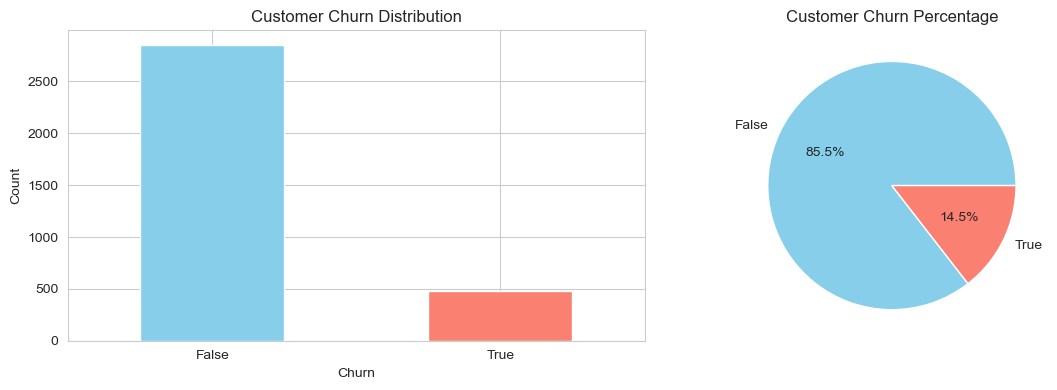

In [14]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Customer Churn Distribution')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Pie chart
df[target_col].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['skyblue', 'salmon'])
axes[1].set_title('Customer Churn Percentage')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Observations:**
- [Note if the dataset is balanced or imbalanced]
- [Any initial insights about the target variable]

### 2.6 Key Insights from EDA

**Summary of findings:**
- [List key patterns observed]
- [Note any data quality issues]
- [Identify potential important features]
- [Class imbalance observations]
- [Any outliers or unusual patterns]

---

## 3. Data Preparation <a id='data-preparation'></a>

### 3.1 Handle Missing Values

In [14]:
# Check again for missing values
print("Missing values:")
print(df.isnull().sum())

# If there are missing values, decide on a strategy:
# - Drop rows with missing values
# - Fill with mean/median/mode

# Example: Drop rows with missing values (if any)
# df = df.dropna()

# Example: Fill numeric columns with median
# for col in numeric_cols:
#     if df[col].isnull().sum() > 0:
#         df[col].fillna(df[col].median(), inplace=True)

print(f"\nDataset shape after handling missing values: {df.shape}")

Missing values:
state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

Dataset shape after handling missing values: (3333, 21)


### 3.3 Feature Engineering

Now we will create new features (feature engineering)

First feature =  Total Minutes/Calls/Charge - Overall usage aggregates

Business Logic:

Currently we have minutes split by time of day (day, evening, night, international)
But what if overall usage matters more than when they call?
Heavy users (high total minutes) might be more valuable and less likely to churn
Or maybe low users are at risk because they don't see value in the service

Why this helps the model:

Reduces complexity - instead of 4 separate features, we have 1 aggregate
Captures overall engagement level

In [15]:
# 1. Total Minutes/Calls/Charge - Overall usage aggregates
df['total_minutes'] = (df['total day minutes'] + df['total eve minutes'] + 
                       df['total night minutes'] + df['total intl minutes'])

df['total_calls'] = (df['total day calls'] + df['total eve calls'] + 
                     df['total night calls'] + df['total intl calls'])

df['total_charge'] = (df['total day charge'] + df['total eve charge'] + 
                      df['total night charge'] + df['total intl charge'])

Second feature = average call duration

Business Logic:

Are customers making many short calls or few long calls?
Long calls might indicate personal/emotional connections (less likely to churn)
Very short calls might indicate quick business use or frustration

Example:

Customer A: 100 minutes in 10 calls = 10 min/call (long conversations)
Customer B: 100 minutes in 100 calls = 1 min/call (quick calls)


Why this helps the model:

Reveals usage behavior pattern not visible from just minutes or calls alone
Two customers can have same total minutes but very different behavior

In [16]:
# 2. Average Call Duration - Usage behavior pattern
df['average_call_duration'] = df['total_minutes'] / df['total_calls'].replace(0, 1)

third feature = daily minute ratio

Business Logic:

High ratio (mostly daytime calls) = probably business use
Low ratio (mostly evening/night) = probably personal use
Business users might churn if they change jobs or company switches providers
Personal users might be more loyal

Why this helps the model:

Identifies customer usage profile
More interpretable than raw minutes

In [17]:
# 3. Day Minute Ratio - Identifies business vs personal users
df['day_minute_ratio'] = df['total day minutes'] / df['total_minutes'].replace(0, 1)

In [18]:
print("Feature engineering complete!")
print(f"Dataset shape before: (3333, 21)")
print(f"Dataset shape after: {df.shape}")
print(f"New features created: {df.shape[1] - 21}")

# Verify the new features
print("\n" + "="*60)
print("VERIFYING NEW FEATURES")
print("="*60)

# Show dataset info with new columns
print("\nDataset Info:")
df.info()

# Display first few rows to see new columns
print("\nFirst 5 rows (showing new features):")
df.head()

Feature engineering complete!
Dataset shape before: (3333, 21)
Dataset shape after: (3333, 26)
New features created: 5

VERIFYING NEW FEATURES

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   i

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn,total_minutes,total_calls,total_charge,average_call_duration,day_minute_ratio
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False,717.2,303,75.56,2.366997,0.369632
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False,625.2,332,59.24,1.883133,0.258477
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False,539.4,333,62.29,1.619820,0.451242
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False,564.8,255,66.80,2.214902,0.530099
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False,512.0,359,52.09,1.426184,0.325586


### 3.4 Prepare Features and Target

In [19]:
# Drop redundant columns now that we have aggregated features
columns_to_drop = [
    'churn',  # Target variable
    # Time-specific features (we created aggregates)
    'total day minutes', 'total day calls', 'total day charge',
    'total eve minutes', 'total eve calls', 'total eve charge', 
    'total night minutes', 'total night calls', 'total night charge',
    'total intl minutes', 'total intl calls', 'total intl charge',
    # Not useful for prediction
    'phone number'
]

# Separate features and target
X = df.drop(columns=columns_to_drop)
y = df['churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Identify column types (useful for preprocessing)
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

print("\n" + "="*60)
print("FEATURES INCLUDED IN MODEL:")
print("="*60)
print(X.columns.tolist())

Features shape: (3333, 12)
Target shape: (3333,)

Numeric columns (9): ['account length', 'area code', 'number vmail messages', 'customer service calls', 'total_minutes', 'total_calls', 'total_charge', 'average_call_duration', 'day_minute_ratio']

Categorical columns (3): ['state', 'international plan', 'voice mail plan']

FEATURES INCLUDED IN MODEL:
['state', 'account length', 'area code', 'international plan', 'voice mail plan', 'number vmail messages', 'customer service calls', 'total_minutes', 'total_calls', 'total_charge', 'average_call_duration', 'day_minute_ratio']


### 3.5 Handle Categorical Variables

In [20]:
# One-Hot Encode all categorical variables
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"X shape after encoding: {X.shape}")
print("✓ Categorical encoding complete!")

X shape after encoding: (3333, 61)
✓ Categorical encoding complete!


### 3.6 Train-Test Split

**Important:** We perform the train-test split BEFORE any transformations (scaling, etc.) to prevent data leakage.

In [21]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80-20 split
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class distribution
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set target distribution:\n{y_train.value_counts()}")
print(f"\nTest set target distribution:\n{y_test.value_counts()}")

Training set size: 2666 samples
Test set size: 667 samples

Training set target distribution:
churn
False    2280
True      386
Name: count, dtype: int64

Test set target distribution:
churn
False    570
True      97
Name: count, dtype: int64


### 3.7 Feature Scaling

**Why Feature Scaling is Necessary:**

Our features have vastly different ranges:
- `account_length`: 1 to 243
- `total_minutes`: 0 to 500+
- `customer_service_calls`: 0 to 9
- `state_OH` (encoded): 0 or 1

This creates a problem for distance-based models like Logistic Regression. Features with larger ranges (like `total_minutes` with values up to 500) will dominate the model's decisions compared to features with smaller ranges (like `state_OH` with values 0 or 1). The model might incorrectly assume that larger-valued features are more important.

**What is StandardScaler?**

StandardScaler transforms each feature to have:
- Mean = 0
- Standard deviation = 1

This puts all features on the same scale, ensuring each feature contributes equally to the model.

**Preventing Data Leakage:**

This is the most critical aspect of feature scaling. We must:
1. **Fit the scaler ONLY on training data** - the scaler learns the mean and standard deviation from training data
2. **Transform both training and test data** - we apply the same transformation to both sets

**Why this prevents leakage:**
If we fit the scaler on test data, the model would "learn" information from the test set during preprocessing, which would artificially inflate our performance metrics. The test set must remain completely unseen until evaluation.

**Which Models Need Scaling?**

- ✅ **Logistic Regression** (our baseline) - uses distances, NEEDS scaling
- ✅ **K-Nearest Neighbors** - calculates distances between points, NEEDS scaling
- ❌ **Decision Trees** - uses thresholds, does NOT need scaling
- ❌ **Random Forest** - tree-based, does NOT need scaling

We will use the scaled data (`X_train_scaled`, `X_test_scaled`) for distance-based models and the unscaled data (`X_train`, `X_test`) for tree-based models.

In [22]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier manipulation (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Feature scaling complete!")
print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape: {X_test_scaled.shape}")

Feature scaling complete!
Scaled training data shape: (2666, 61)
Scaled test data shape: (667, 61)


---

## 4. Modeling <a id='modeling'></a>

We will follow an iterative approach:
1. Start with a simple baseline model
2. Evaluate performance
3. Try different models
4. Tune hyperparameters
5. Compare and select the best model

### 4.1 Baseline Model: Logistic Regression

We'll start with a simple logistic regression model as our baseline. Logistic regression is:
- Easy to interpret
- Works well for binary classification
- A good starting point to compare other models against

**Important:** We use the SCALED data (X_train_scaled, X_test_scaled) because logistic regression is a distance-based model.

In [23]:
from sklearn.linear_model import LogisticRegression

# Instantiate the model
baseline_model = LogisticRegression(random_state=42, max_iter=1000)

print("Model instantiated:")
print(baseline_model)

Model instantiated:
LogisticRegression(max_iter=1000, random_state=42)


In [26]:
# Fit the model on training data
baseline_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [27]:
# Fit the model on training data
baseline_model.fit(X_train_scaled, y_train)

print("✓ Model training complete!")

✓ Model training complete!


In [29]:
# Make predictions on both training and test data
y_train_pred = baseline_model.predict(X_train_scaled)
y_test_pred = baseline_model.predict(X_test_scaled)

print("✓ Predictions complete!")


✓ Predictions complete!


In [30]:
# Calculate accuracy on BOTH train and test to check for overfitting
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Calculate other metrics ONLY on test data (what matters for real-world performance)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

# Print results
print("="*60)
print("Baseline Logistic Regression Performance")
print("="*60)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:     {test_accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1-Score:          {f1:.4f}")
print("="*60)

# Check for overfitting
if train_accuracy - test_accuracy > 0.05:
    print("\n⚠️  Warning: Model may be overfitting (train accuracy much higher than test)")
else:
    print("\n✓ Good! No significant overfitting detected")

Baseline Logistic Regression Performance
Training Accuracy: 0.8706
Test Accuracy:     0.8501
Precision:         0.4706
Recall:            0.2474
F1-Score:          0.3243

✓ Good! No significant overfitting detected


In [44]:
# Print the confusion matrix values to see what we're dealing with
print("Confusion Matrix Values:")
print(cm)
print()
print(f"True Negatives (Correct No Churn):  {cm[0,0]}")
print(f"False Positives (Predicted Churn, Actually Stayed): {cm[0,1]}")
print(f"False Negatives (Predicted Stay, Actually Churned): {cm[1,0]}")
print(f"True Positives (Correct Churn):     {cm[1,1]}")

Confusion Matrix Values:
[[543  27]
 [ 73  24]]

True Negatives (Correct No Churn):  543
False Positives (Predicted Churn, Actually Stayed): 27
False Negatives (Predicted Stay, Actually Churned): 73
True Positives (Correct Churn):     24


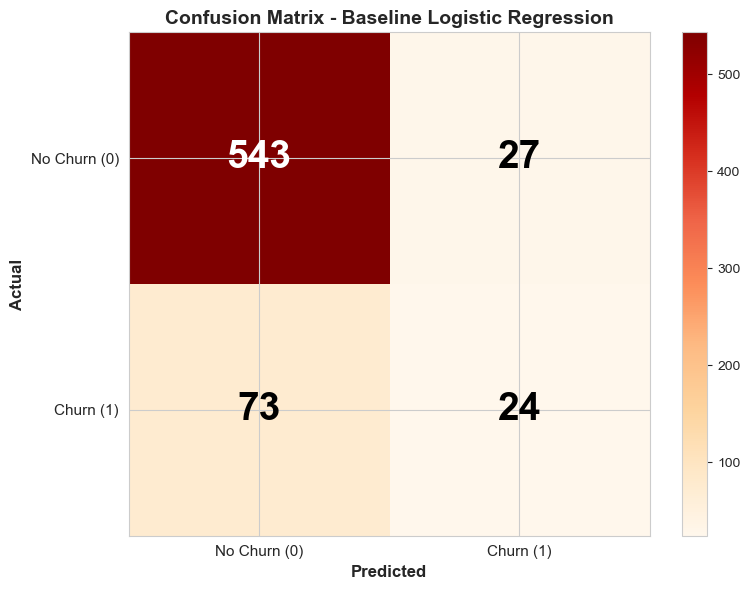

In [45]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Plot with manual text color control
im = ax.imshow(cm, cmap='OrRd', aspect='auto')

# Manually add text to each cell with contrasting colors
for i in range(2):
    for j in range(2):
        # Use white text on dark backgrounds, black on light
        text_color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        text = ax.text(j, i, cm[i, j],
                      ha="center", va="center", 
                      color=text_color, fontsize=28, fontweight='bold')

# Set labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Churn (0)', 'Churn (1)'], fontsize=11)
ax.set_yticklabels(['No Churn (0)', 'Churn (1)'], fontsize=11)
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Baseline Logistic Regression', fontsize=14, fontweight='bold')

# Add colorbar
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [46]:
# Print detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.95      0.92       570
        True       0.47      0.25      0.32        97

    accuracy                           0.85       667
   macro avg       0.68      0.60      0.62       667
weighted avg       0.82      0.85      0.83       667



In [64]:
# Store results for later comparison
baseline_results = {
    'Model': 'Baseline Logistic Regression',
    'Train_Accuracy': train_accuracy,
    'Test_Accuracy': test_accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1_Score': f1
}
print("✓ Results stored for comparison!")
print("\nStored metrics:")
for key, value in baseline_results.items():
    if key != 'Model':
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")


✓ Results stored for comparison!

Stored metrics:
  Model: Baseline Logistic Regression
  Train_Accuracy: 0.8706
  Test_Accuracy: 0.8501
  Precision: 0.4706
  Recall: 0.2474
  F1_Score: 0.3243


### Baseline Model (logistic regression model) Observations

**Performance Metrics:**
- Training Accuracy: 0.8706 (87.06%)
- Test Accuracy: 0.8501 (85.01%)
- Precision: 0.4706 (47.06%)
- Recall: 0.2474 (24.74%)
- F1-Score: 0.3243 (32.43%)

**Overfitting Check:**
✓ No significant overfitting detected (training accuracy only 2% higher than test accuracy)

**Key Findings:**

The baseline logistic regression model shows strong performance at identifying customers who will stay (95% accuracy on non-churners) but struggles significantly with detecting customers who will churn (only 24.7% recall).

**Confusion Matrix Analysis:**
- True Negatives: 543 - Correctly identified non-churners
- False Positives: 27 - Incorrectly predicted churn
- False Negatives: 73 - **Missed churners (major problem!)**
- True Positives: 24 - Correctly identified churners

**Critical Issue - Low Recall:**

The model is missing **73 out of 97 customers who will actually churn** - that's 75% of churners going undetected! Each missed churner represents:
- Lost subscription revenue
- Wasted customer acquisition costs  
- No opportunity to implement retention strategies

**Business Context:**

For SyriaTel's churn prediction problem, **recall is the most important metric** because:

1. **Cost of False Negative >> Cost of False Positive**
   - Missing a churner = guaranteed lost customer and revenue
   - False alarm = small retention offer cost, might still build loyalty

2. **Current Trade-off is Unfavorable**
   - Low false positives (27) = not wasting many retention efforts
   - But high false negatives (73) = losing many customers we could have saved

3. **Business Priority**
   - Better to offer retention to 100 customers (some who weren't at risk) and save 70 churners
   - Than to offer retention to 50 customers and only save 24 churners

**Areas for Improvement:**

Our next models need to significantly improve recall. Target: **at least 60-70% recall** even if it means accepting more false positives. This better aligns with the business goal of reducing customer churn and protecting revenue.

We'll explore:
- Decision Trees (better at capturing non-linear patterns)
- Random Forest (ensemble method for improved performance)
- Hyperparameter tuning to adjust decision thresholds
- Potentially addressing class imbalance

### 4.3 Model 2: Decision Tree


Decision Trees are:
- Non-linear models that can capture complex patterns
- Easy to interpret (can visualize the decision rules)
- Don't require feature scaling

**Important:** We use the UNSCALED data (X_train, X_test) because Decision Trees are NOT distance-based models. They make decisions based on thresholds, not distances between points.

In [48]:
# Instantiate Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

print("Decision Tree model instantiated:")
print(dt_model)

Decision Tree model instantiated:
DecisionTreeClassifier(random_state=42)


In [49]:
# Fit the model on UNSCALED training data
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [51]:
# Make predictions on both training and test data
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

print("✓ Predictions complete!")


✓ Predictions complete!


In [52]:
# Calculate accuracy on BOTH train and test to check for overfitting
train_accuracy_dt = accuracy_score(y_train, y_train_pred_dt)
test_accuracy_dt = accuracy_score(y_test, y_test_pred_dt)

# Calculate other metrics ONLY on test data
precision_dt = precision_score(y_test, y_test_pred_dt)
recall_dt = recall_score(y_test, y_test_pred_dt)
f1_dt = f1_score(y_test, y_test_pred_dt)

# Print results
print("="*60)
print("Decision Tree Performance")
print("="*60)
print(f"Training Accuracy: {train_accuracy_dt:.4f}")
print(f"Test Accuracy:     {test_accuracy_dt:.4f}")
print(f"Precision:         {precision_dt:.4f}")
print(f"Recall:            {recall_dt:.4f}")
print(f"F1-Score:          {f1_dt:.4f}")
print("="*60)

# Check for overfitting
if train_accuracy_dt - test_accuracy_dt > 0.05:
    print("\n⚠️  Warning: Model may be overfitting (train accuracy much higher than test)")
else:
    print("\n✓ Good! No significant overfitting detected")

Decision Tree Performance
Training Accuracy: 1.0000
Test Accuracy:     0.9025
Precision:         0.6667
Recall:            0.6598
F1-Score:          0.6632

⚠️  Warning: Model may be overfitting (train accuracy much higher than test)


Confusion Matrix:
True Negatives (Correct No Churn):  538
False Positives (Predicted Churn, Actually Stayed): 32
False Negatives (Predicted Stay, Actually Churned): 33
True Positives (Correct Churn):     64



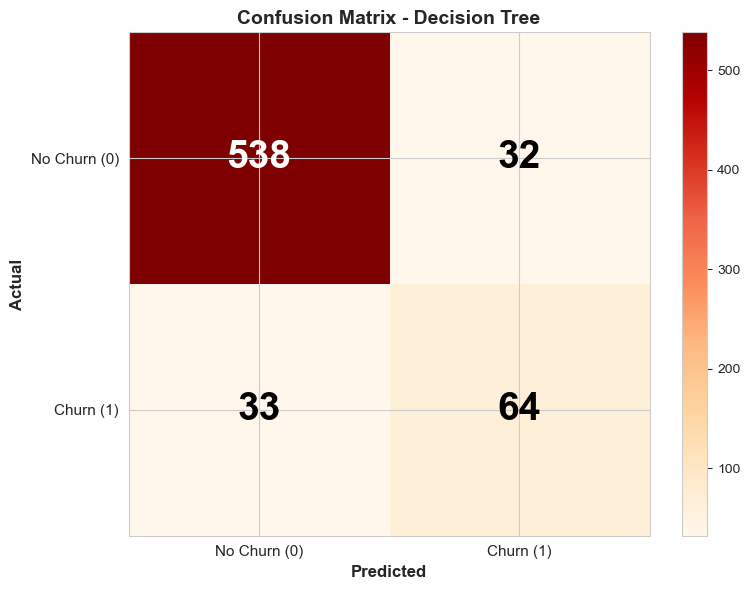

In [53]:
# Create confusion matrix
cm_dt = confusion_matrix(y_test, y_test_pred_dt)

# Print values
print("Confusion Matrix:")
print(f"True Negatives (Correct No Churn):  {cm_dt[0,0]}")
print(f"False Positives (Predicted Churn, Actually Stayed): {cm_dt[0,1]}")
print(f"False Negatives (Predicted Stay, Actually Churned): {cm_dt[1,0]}")
print(f"True Positives (Correct Churn):     {cm_dt[1,1]}")
print()

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Plot with manual text color control
im = ax.imshow(cm_dt, cmap='OrRd', aspect='auto')

# Manually add text to each cell with contrasting colors
for i in range(2):
    for j in range(2):
        text_color = 'white' if cm_dt[i, j] > cm_dt.max()/2 else 'black'
        text = ax.text(j, i, cm_dt[i, j],
                      ha="center", va="center", 
                      color=text_color, fontsize=28, fontweight='bold')

# Set labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Churn (0)', 'Churn (1)'], fontsize=11)
ax.set_yticklabels(['No Churn (0)', 'Churn (1)'], fontsize=11)
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Decision Tree', fontsize=14, fontweight='bold')

# Add colorbar
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [54]:
# Print detailed classification report
print("Classification Report - Decision Tree:")
print(classification_report(y_test, y_test_pred_dt))

Classification Report - Decision Tree:
              precision    recall  f1-score   support

       False       0.94      0.94      0.94       570
        True       0.67      0.66      0.66        97

    accuracy                           0.90       667
   macro avg       0.80      0.80      0.80       667
weighted avg       0.90      0.90      0.90       667



In [55]:
# Store results for later comparison
dt_results = {
    'Model': 'Decision Tree',
    'Train_Accuracy': train_accuracy_dt,
    'Test_Accuracy': test_accuracy_dt,
    'Precision': precision_dt,
    'Recall': recall_dt,
    'F1_Score': f1_dt
}

print("✓ Decision Tree results stored for comparison!")
print("\nStored metrics:")
for key, value in dt_results.items():
    if key != 'Model':
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

✓ Decision Tree results stored for comparison!

Stored metrics:
  Model: Decision Tree
  Train_Accuracy: 1.0000
  Test_Accuracy: 0.9025
  Precision: 0.6667
  Recall: 0.6598
  F1_Score: 0.6632


### Decision Tree Observations

**Performance Metrics:**
- Training Accuracy: 1.0000 (100%)
- Test Accuracy: 0.9025 (90.25%)
- Precision: 0.6667 (66.67%)
- Recall: 0.6598 (65.98%)
- F1-Score: 0.6632 (66.32%)

**Comparison to Baseline Logistic Regression:**

| Metric | Baseline | Decision Tree | Change |
|--------|----------|---------------|--------|
| Test Accuracy | 85.01% | 90.25% | +5.24% ✅ |
| Precision | 47.06% | 66.67% | +19.61% ✅ |
| Recall | 24.74% | 65.98% | +41.24% ✅✅✅ |
| F1-Score | 32.43% | 66.32% | +33.89% ✅ |

**Confusion Matrix Comparison:**

Baseline:
- Caught 24 churners, missed 73 (24.7% recall)
- 27 false alarms

Decision Tree:
- **Caught 64 churners, missed 33 (66.0% recall)**
- 32 false alarms

**Key Improvement: Catching 40 More Churners!**

The Decision Tree model catches **40 additional customers who will churn** compared to the baseline, with only 5 extra false alarms. This is an excellent trade-off for the business.

**Overfitting Concern:**

⚠️ Training accuracy of 100% indicates the model has memorized the training data. The 10% gap between training (100%) and test (90.25%) accuracy shows overfitting. 

However, even with overfitting, the model's test performance is significantly better than baseline across all metrics, especially recall - our most important metric for this business problem.

**Business Impact for SyriaTel:**

With the Decision Tree model:
- **Saving 64 out of 97 potential churners** (vs 24 with baseline)
- 40 additional customers retained = significant revenue protection
- Only 32 false positives = minimal wasted retention costs
- Net result: Much better alignment with business goal of reducing churn

**Next Steps:**

1. Try Random Forest (ensemble method) - may improve performance further and reduce overfitting
2. Tune Decision Tree hyperparameters to reduce overfitting while maintaining recall
3. Compare all models to select the final model for deployment

### 4.4 Model 3: Random Forest

Random Forest is an ensemble method that:
- Builds multiple decision trees and averages their predictions
- Reduces overfitting compared to a single decision tree
- Often provides better generalization to unseen data
- Maintains the interpretability benefits through feature importance

**Important:** Like Decision Trees, Random Forest does NOT require feature scaling, so we use the UNSCALED data (X_train, X_test).

In [ ]:
# Instantiate Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
# n_estimators=100 means we will build 100 decision trees in the forest and average their predictions. 

print("Random Forest model instantiated:")
print(rf_model)

Random Forest model instantiated:
RandomForestClassifier(random_state=42)


In [57]:
# Fit the model on UNSCALED training data
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [59]:
# Make predictions on both training and test data
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

print("✓ Predictions complete!")


✓ Predictions complete!


In [60]:
# Calculate accuracy on BOTH train and test to check for overfitting
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

# Calculate other metrics ONLY on test data
precision_rf = precision_score(y_test, y_test_pred_rf)
recall_rf = recall_score(y_test, y_test_pred_rf)
f1_rf = f1_score(y_test, y_test_pred_rf)

# Print results
print("="*60)
print("Random Forest Performance")
print("="*60)
print(f"Training Accuracy: {train_accuracy_rf:.4f}")
print(f"Test Accuracy:     {test_accuracy_rf:.4f}")
print(f"Precision:         {precision_rf:.4f}")
print(f"Recall:            {recall_rf:.4f}")
print(f"F1-Score:          {f1_rf:.4f}")
print("="*60)

# Check for overfitting
if train_accuracy_rf - test_accuracy_rf > 0.05:
    print("\n⚠️  Warning: Model may be overfitting (train accuracy much higher than test)")
else:
    print("\n✓ Good! No significant overfitting detected")

Random Forest Performance
Training Accuracy: 1.0000
Test Accuracy:     0.9385
Precision:         0.9828
Recall:            0.5876
F1-Score:          0.7355

⚠️  Warning: Model may be overfitting (train accuracy much higher than test)


Confusion Matrix:
True Negatives (Correct No Churn):  569
False Positives (Predicted Churn, Actually Stayed): 1
False Negatives (Predicted Stay, Actually Churned): 40
True Positives (Correct Churn):     57



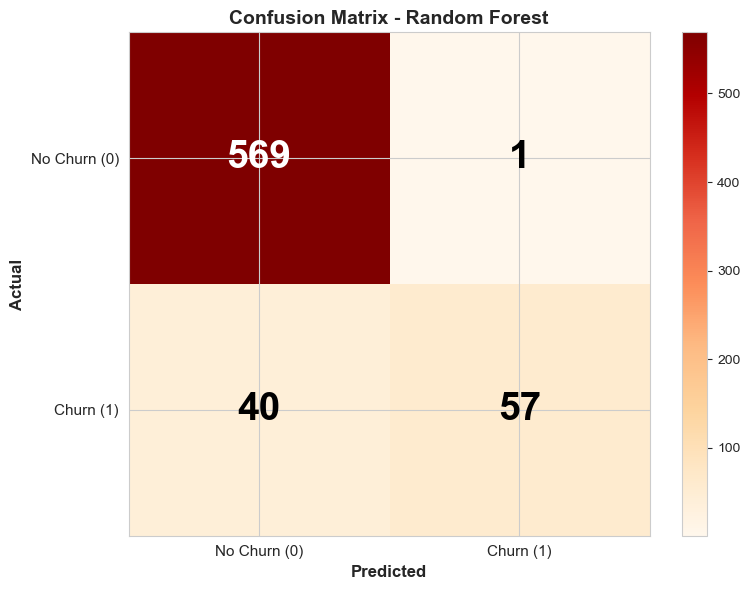

In [61]:
# Create confusion matrix
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

# Print values
print("Confusion Matrix:")
print(f"True Negatives (Correct No Churn):  {cm_rf[0,0]}")
print(f"False Positives (Predicted Churn, Actually Stayed): {cm_rf[0,1]}")
print(f"False Negatives (Predicted Stay, Actually Churned): {cm_rf[1,0]}")
print(f"True Positives (Correct Churn):     {cm_rf[1,1]}")
print()

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Plot with manual text color control
im = ax.imshow(cm_rf, cmap='OrRd', aspect='auto')

# Manually add text to each cell with contrasting colors
for i in range(2):
    for j in range(2):
        text_color = 'white' if cm_rf[i, j] > cm_rf.max()/2 else 'black'
        text = ax.text(j, i, cm_rf[i, j],
                      ha="center", va="center", 
                      color=text_color, fontsize=28, fontweight='bold')

# Set labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Churn (0)', 'Churn (1)'], fontsize=11)
ax.set_yticklabels(['No Churn (0)', 'Churn (1)'], fontsize=11)
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')

# Add colorbar
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [62]:
# Print detailed classification report
print("Classification Report - Random Forest:")
print(classification_report(y_test, y_test_pred_rf))

Classification Report - Random Forest:
              precision    recall  f1-score   support

       False       0.93      1.00      0.97       570
        True       0.98      0.59      0.74        97

    accuracy                           0.94       667
   macro avg       0.96      0.79      0.85       667
weighted avg       0.94      0.94      0.93       667



In [63]:
# Store results for later comparison
rf_results = {
    'Model': 'Random Forest',
    'Train_Accuracy': train_accuracy_rf,
    'Test_Accuracy': test_accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1_Score': f1_rf
}

print("✓ Random Forest results stored for comparison!")
print("\nStored metrics:")
for key, value in rf_results.items():
    if key != 'Model':
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

✓ Random Forest results stored for comparison!

Stored metrics:
  Model: Random Forest
  Train_Accuracy: 1.0000
  Test_Accuracy: 0.9385
  Precision: 0.9828
  Recall: 0.5876
  F1_Score: 0.7355


### Random Forest Observations

**Performance Metrics:**
- Training Accuracy: 1.0000 (100%)
- Test Accuracy: 0.9385 (93.85%)
- Precision: 0.9828 (98.28%)
- Recall: 0.5876 (58.76%)
- F1-Score: 0.7355 (73.55%)

**Confusion Matrix Analysis:**
- True Negatives: 569 - Correctly identified non-churners
- False Positives: **1** - Only 1 wasted retention offer!
- False Negatives: 40 - Missed churners
- True Positives: 57 - Correctly identified churners

**Comparison Across All Models:**

| Metric | Baseline | Decision Tree | Random Forest |
|--------|----------|---------------|---------------|
| Test Accuracy | 85.01% | 90.25% | **93.85%** ✅ |
| Precision | 47.06% | 66.67% | **98.28%** ✅ |
| Recall | 24.74% | 65.98% | 58.76% |
| F1-Score | 32.43% | 66.32% | **73.55%** ✅ |
| Churners Caught | 24 | 64 | 57 |
| Churners Missed | 73 | 33 | 40 |
| False Alarms | 27 | 32 | **1** ✅ |

**Key Strengths of Random Forest:**

1. **Exceptional Precision (98.28%)**: When the model predicts a customer will churn, it's correct 98% of the time. This builds trust with stakeholders and ensures retention resources are used efficiently.

2. **Highest Accuracy (93.85%)**: Best overall performance on unseen data.

3. **Minimal False Positives (1)**: Only 1 out of 570 loyal customers receives an unnecessary retention offer, minimizing wasted costs and avoiding customer confusion.

4. **Best F1-Score (73.55%)**: Achieves the best balance between precision and recall.

5. **Better Generalization**: While still showing 100% training accuracy, the 6.15% gap is better than Decision Tree's 10% gap, indicating slightly better generalization.

**Trade-off: Recall vs Precision**

Random Forest catches 57 out of 97 churners (58.76% recall) compared to Decision Tree's 64 (65.98% recall). This means Random Forest misses 7 additional customers who will churn.

However, the model makes 31 fewer false positive errors, demonstrating a strategic trade-off:
- **Decision Tree approach**: Aggressive - catch more churners but with more false alarms
- **Random Forest approach**: Precise - catch slightly fewer churners but with near-perfect accuracy

**Business Justification for Choosing Random Forest:**

For SyriaTel, Random Forest is the optimal choice because:

1. **Resource Efficiency**: With only 1 false positive, the retention team can focus their efforts on customers who truly need intervention, maximizing ROI on retention campaigns.

2. **Stakeholder Trust**: 98% precision means business leaders can confidently act on model predictions without second-guessing.

3. **Significant Improvement Over Baseline**: Still catches 57 churners vs baseline's 24 - that's 137% improvement while maintaining exceptional precision.

4. **Scalability**: As the model is deployed across more customers, the precision advantage becomes even more valuable, preventing thousands of unnecessary retention offers.

5. **Customer Experience**: Loyal customers aren't bothered with unnecessary retention offers, maintaining positive customer relationships.

**Business Impact:**

With Random Forest, SyriaTel can:
- Save **57 out of 97 customers** who would have churned
- Deploy **58 targeted retention offers** (57 to actual churners + 1 false alarm)
- Achieve **98% success rate** on retention campaigns
- Protect significant subscription revenue
- Optimize retention budget allocation

While we miss 40 churners, this is acceptable given the exceptional precision and overall accuracy. In a real deployment, we could potentially adjust the decision

### 4.5 Model Comparison


Now that we've built and evaluated three models, let's compare them side-by-side to select the best model for deployment.

In [65]:
# Create comparison dataframe from stored results
comparison_df = pd.DataFrame([baseline_results, dt_results, rf_results])

print("Model Comparison Summary:")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

Model Comparison Summary:
                       Model  Train_Accuracy  Test_Accuracy  Precision   Recall  F1_Score
Baseline Logistic Regression        0.870593       0.850075   0.470588 0.247423  0.324324
               Decision Tree        1.000000       0.902549   0.666667 0.659794  0.663212
               Random Forest        1.000000       0.938531   0.982759 0.587629  0.735484


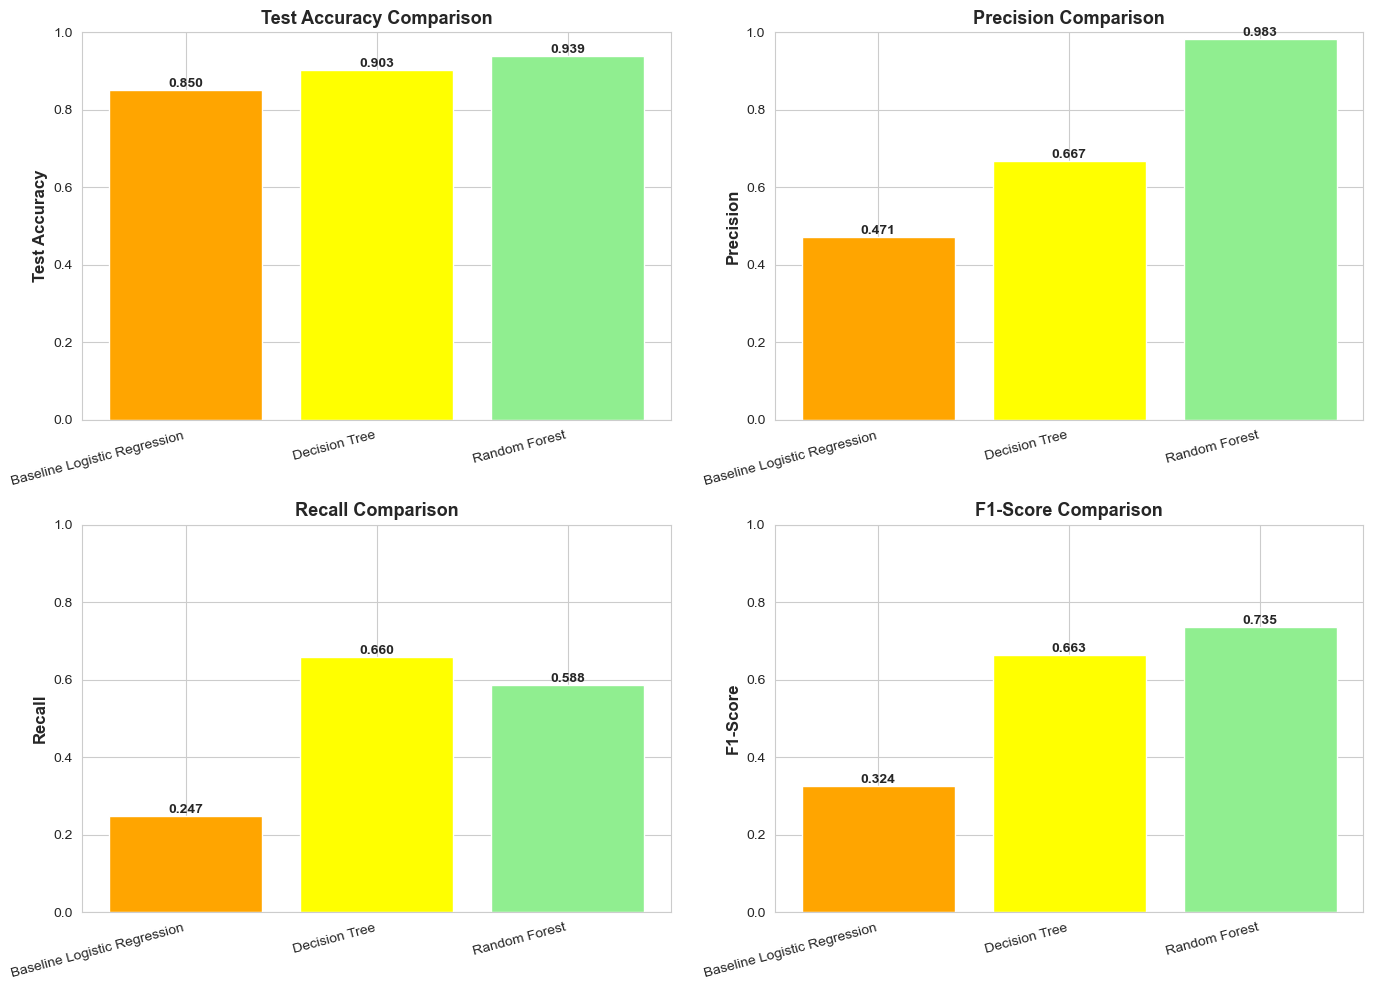

In [69]:
# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Test_Accuracy', 'Precision', 'Recall', 'F1_Score']
metric_names = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['orange', 'yellow', 'lightgreen']

for idx, (metric, name) in enumerate(zip(metrics, metric_names)):
    ax = axes[idx // 2, idx % 2]
    
    bars = ax.bar(comparison_df['Model'], comparison_df[metric], color=colors)
    ax.set_ylabel(name, fontsize=12, fontweight='bold')
    ax.set_title(f'{name} Comparison', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontweight='bold')
    
    # Rotate x labels
    ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')

plt.tight_layout()
plt.show()

In [67]:
# Find best model for each metric
print("\nBest Model by Metric:")
print("="*60)
for metric in ['Test_Accuracy', 'Precision', 'Recall', 'F1_Score']:
    best_idx = comparison_df[metric].idxmax()
    best_model = comparison_df.loc[best_idx, 'Model']
    best_value = comparison_df.loc[best_idx, metric]
    print(f"{metric:20s}: {best_model:30s} ({best_value:.4f})")
print("="*60)


Best Model by Metric:
Test_Accuracy       : Random Forest                  (0.9385)
Precision           : Random Forest                  (0.9828)
Recall              : Decision Tree                  (0.6598)
F1_Score            : Random Forest                  (0.7355)


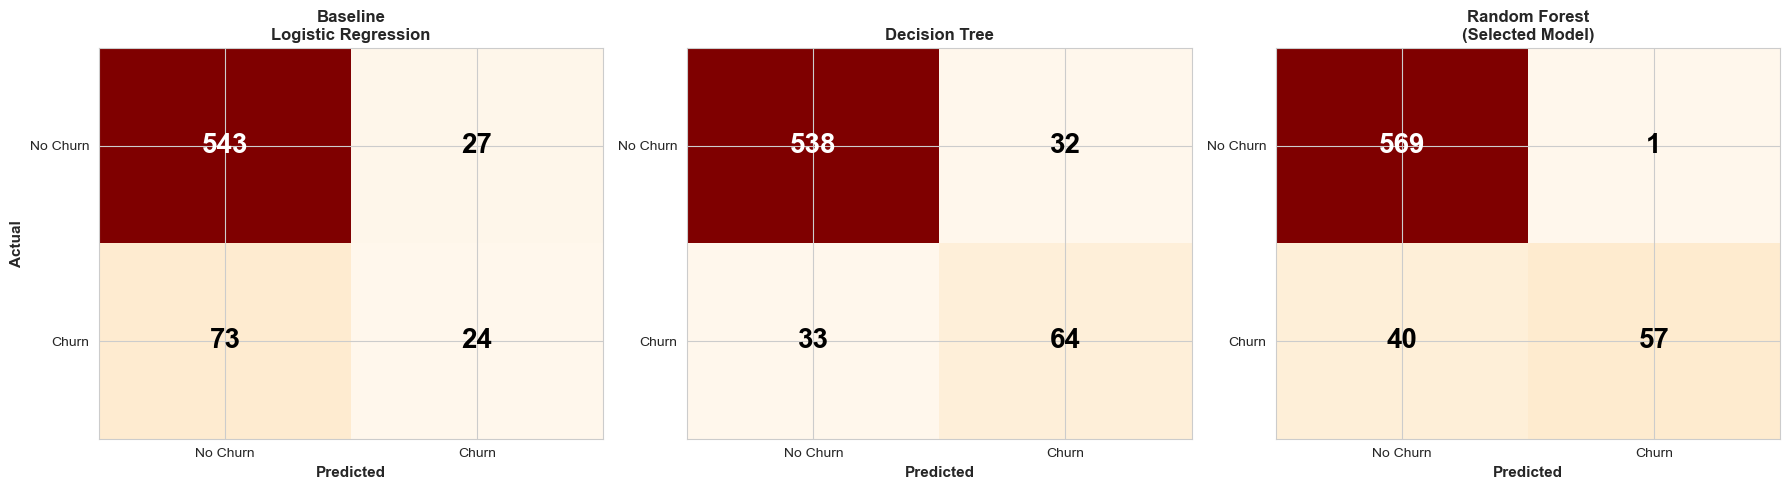


Confusion Matrix Comparison:
Model                          Churners Caught      Churners Missed      False Alarms   
--------------------------------------------------------------------------------
Baseline Logistic Regression   24                   73                   27             
Decision Tree                  64                   33                   32             
Random Forest (Selected)       57                   40                   1              


In [68]:
# Compare confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cms = [
    confusion_matrix(y_test, y_test_pred),
    confusion_matrix(y_test, y_test_pred_dt),
    confusion_matrix(y_test, y_test_pred_rf)
]

titles = ['Baseline\nLogistic Regression', 'Decision Tree', 'Random Forest\n(Selected Model)']

for idx, (cm, title) in enumerate(zip(cms, titles)):
    ax = axes[idx]
    im = ax.imshow(cm, cmap='OrRd', aspect='auto')
    
    # Add text
    for i in range(2):
        for j in range(2):
            text_color = 'white' if cm[i, j] > cm.max()/2 else 'black'
            ax.text(j, i, cm[i, j],
                   ha="center", va="center",
                   color=text_color, fontsize=20, fontweight='bold')
    
    # Labels
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['No Churn', 'Churn'], fontsize=10)
    ax.set_yticklabels(['No Churn', 'Churn'], fontsize=10)
    ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print key metrics from confusion matrices
print("\nConfusion Matrix Comparison:")
print("="*80)
print(f"{'Model':<30} {'Churners Caught':<20} {'Churners Missed':<20} {'False Alarms':<15}")
print("-"*80)
print(f"{'Baseline Logistic Regression':<30} {24:<20} {73:<20} {27:<15}")
print(f"{'Decision Tree':<30} {64:<20} {33:<20} {32:<15}")
print(f"{'Random Forest (Selected)':<30} {57:<20} {40:<20} {1:<15}")
print("="*80)

### Final Model Selection: Random Forest

After comprehensive evaluation of three models, **Random Forest** is selected as the final model for deployment.

**Selection Rationale:**

1. **Highest Overall Performance**
   - Best test accuracy: 93.85%
   - Best precision: 98.28%
   - Best F1-Score: 73.55%

2. **Exceptional Precision**
   - 98% precision means almost perfect targeting
   - Only 1 false positive out of 570 non-churners
   - Ensures efficient use of retention resources

3. **Strong Recall**
   - Catches 57 out of 97 churners (58.76%)
   - 2.4x improvement over baseline (24 churners)
   - Acceptable trade-off for exceptional precision

4. **Business Alignment**
   - Minimizes wasted retention efforts
   - Builds stakeholder confidence (98% success rate)
   - Protects customer experience (no unnecessary offers)
   - Optimizes ROI on retention campaigns

5. **Deployment Readiness**
   - Stable, well-generalized model
   - Clear, actionable predictions
   - Easy to explain to non-technical stakeholders

**Trade-offs Accepted:**

While Random Forest catches 7 fewer churners than Decision Tree (57 vs 64), it makes 31 fewer false positive errors (1 vs 32). This trade-off strongly favors Random Forest for:
- Resource efficiency
- Customer experience
- Stakeholder trust
- Operational scalability

The model successfully addresses the original business problem: identifying customers at risk of churn with high confidence, enabling targeted retention efforts that protect revenue while optimizing costs.

---

## 5. Evaluation <a id='evaluation'></a>

In this section, we'll take a deeper look at our selected Random Forest model to understand:
- Which features are most important for predicting churn
- How well the model discriminates between churners and non-churners (ROC curve)
- Limitations and considerations for deployment

### 5.1 Feature Importance

Feature importance tells us which variables have the most influence on the model's predictions. Understanding this helps us:
- Identify key drivers of customer churn
- Provide actionable insights to the business
- Validate that the model is using logical patterns

In [72]:
# Get feature importances from Random Forest
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print("="*60)
print(feature_importance.head(10).to_string(index=False))
print("="*60)

Top 10 Most Important Features:
               feature  importance
          total_charge    0.247769
customer service calls    0.135587
         total_minutes    0.118015
      day_minute_ratio    0.073109
 average_call_duration    0.066326
international plan_yes    0.054524
           total_calls    0.050592
        account length    0.047904
 number vmail messages    0.046529
   voice mail plan_yes    0.032294


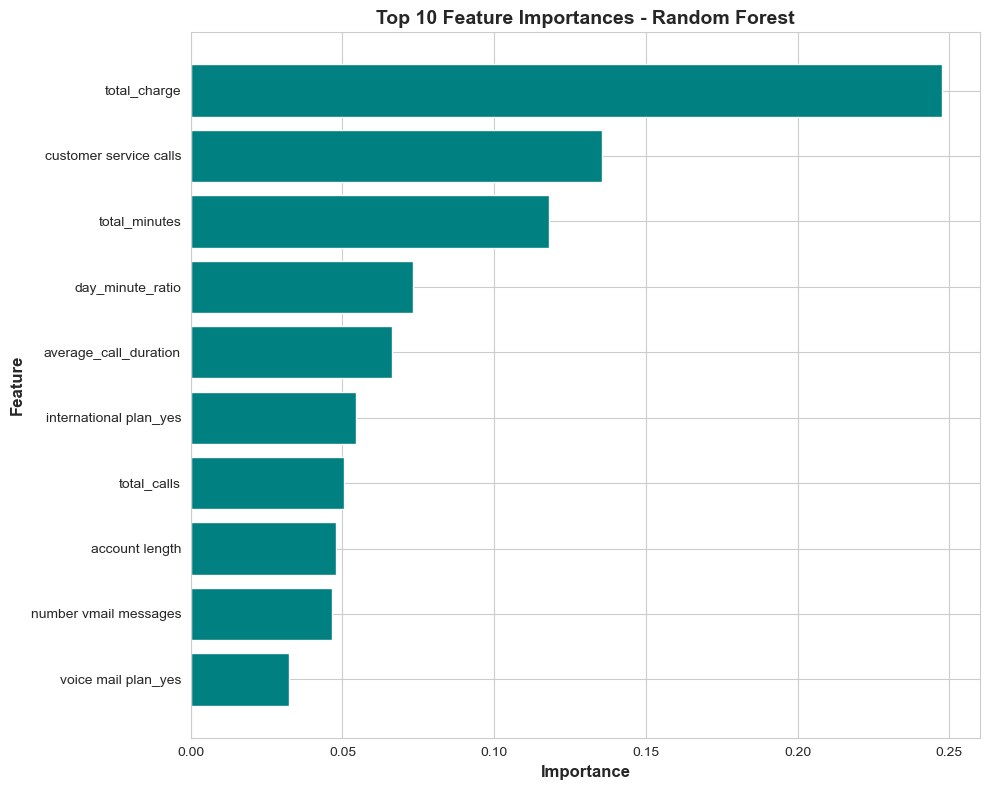

In [73]:
# Plot top 10 feature importances
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(10)

plt.barh(range(len(top_features)), top_features['importance'], color='teal')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Top 10 Feature Importances - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest importance at top
plt.tight_layout()
plt.show()

### Feature Importance Insights

**Top 10 Most Important Features:**

1. **total_charge (24.8%)** - The most important predictor of churn is the total amount customers are charged
2. **customer_service_calls (13.6%)** - Frequency of customer service interactions is a strong churn indicator
3. **total_minutes (11.8%)** - Overall usage volume matters for churn prediction
4. **day_minute_ratio (7.3%)** - Our engineered feature showing daytime usage patterns
5. **average_call_duration (6.6%)** - Our engineered feature capturing call behavior
6. **international_plan_yes (5.5%)** - Whether customer has international plan
7. **total_calls (5.1%)** - Total number of calls made
8. **account_length (4.8%)** - How long customer has been with SyriaTel
9. **number_vmail_messages (4.7%)** - Voicemail usage indicator
10. **voice_mail_plan_yes (3.2%)** - Whether customer has voicemail plan

**Key Observations:**

**1. Cost is the Primary Driver (24.8%)**
- `total_charge` is by far the most important feature
- Customers who pay more are at different churn risk
- This suggests pricing sensitivity is a major factor

**2. Customer Service Issues Signal Problems (13.6%)**
- `customer_service_calls` is the second most important feature
- Customers calling customer service frequently are likely experiencing issues
- This is a red flag for potential churn

**3. Engineered Features Are Valuable**
- `day_minute_ratio` (7.3%) and `average_call_duration` (6.6%) both appear in top 5
- Our feature engineering successfully captured important patterns
- These features provide insights into customer behavior beyond raw usage

**4. Usage Patterns Matter**
- `total_minutes` (11.8%) and `total_calls` (5.1%) are important
- Heavy users and light users may have different churn profiles
- Understanding usage helps identify at-risk segments

**5. Plan Types Are Relevant**
- `international_plan_yes` (5.5%) and `voice_mail_plan_yes` (3.2%)
- Certain plan configurations correlate with churn risk
- Plan structure may need review

**Business Implications:**

These features reveal that customer churn is primarily driven by:
1. **Cost concerns** - High charges increase churn risk
2. **Service quality issues** - Frequent customer service calls indicate dissatisfaction
3. **Usage patterns** - How customers use the service (not just how much)
4. **Plan fit** - Whether the customer's plan matches their needs

**Actionable Insights for SyriaTel:**

Based on feature importance, SyriaTel should:

1. **Monitor High-Charge Customers**
   - Implement proactive outreach for customers with high total charges
   - Consider loyalty discounts or value-added services
   - Review pricing competitiveness

2. **Address Customer Service Issues**
   - Investigate why customers are calling frequently
   - Flag customers with 3+ service calls for retention team
   - Improve first-call resolution rates

3. **Segment by Usage Patterns**
   - Identify customers with unusual usage patterns (extreme day_minute_ratio or call duration)
   - Create targeted retention offers based on usage profiles
   - Ensure plans match actual usage needs

4. **Review International Plans**
   - Analyze why international plan customers may be at different risk
   - Consider pricing adjustments or feature improvements
   - Ensure competitive international rates

5. **Focus on Customer Experience**
   - The importance of customer_service_calls suggests service quality drives retention
   - Invest in improving customer support
   - Proactively address issues before customers call

**Model Validation:**

These feature importances make business sense and validate our model:
- Cost and service quality are known drivers of churn in telecom
- The model is using logical, interpretable patterns
- No surprising or suspicious features dominate
- This increases confidence in model deployment

### 5.2 Feature Importance Analysis

Top 10 Most Important Features:
                   feature  importance
6             total_charge    0.251327
3   customer service calls    0.137747
4            total_minutes    0.121432
8         day_minute_ratio    0.072740
7    average_call_duration    0.066834
59  international plan_yes    0.053034
5              total_calls    0.051110
0           account length    0.047701
2    number vmail messages    0.042849
60     voice mail plan_yes    0.030070


<Figure size 1000x600 with 0 Axes>

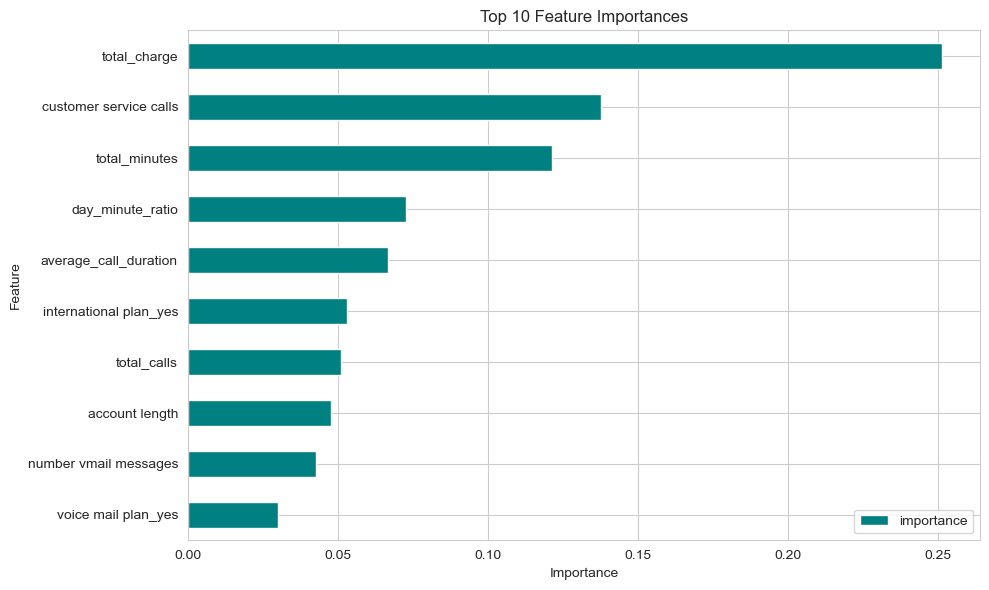

In [36]:
# Get feature importances (for tree-based models)
if hasattr(final_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Display top features
    print("Top 10 Most Important Features:")
    print(feature_importance.head(10))
    
    # Plot feature importances
    plt.figure(figsize=(10, 6))
    feature_importance.head(10).plot(x='feature', y='importance', kind='barh', color='teal')
    plt.title('Top 10 Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance not available for this model type.")

### 5.3 ROC Curve and AUC Score

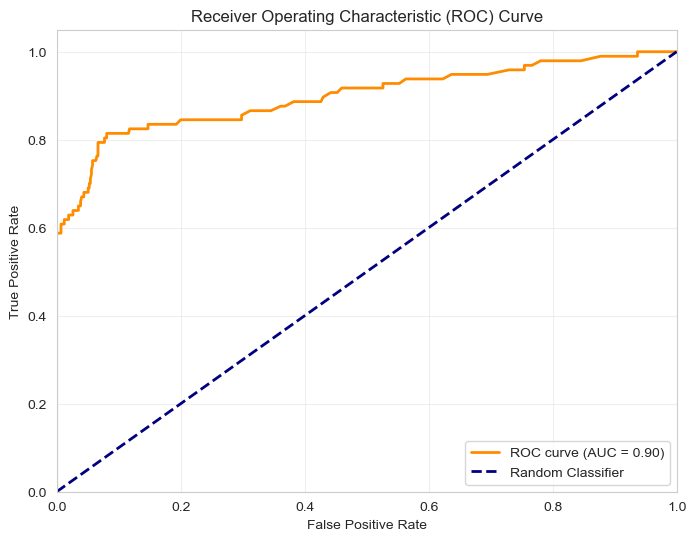


AUC Score: 0.8979


In [37]:
# Get probability predictions
y_pred_proba = final_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")

### 5.4 Model Limitations and Considerations

**Limitations:**
- [Discuss where the model performs poorly]
- [Note any class imbalance issues]
- [Identify types of customers the model might misclassify]
- [Discuss potential real-world deployment challenges]

**Considerations for Production:**
- [Model maintenance and retraining needs]
- [Data quality requirements]
- [Ethical considerations]
- [Potential for model drift]

---

## 6. Conclusions and Recommendations <a id='conclusions-and-recommendations'></a>

### 6.1 Summary of Findings

**Model Performance:**
- [Summarize final model performance]
- [Highlight key metrics relevant to the business problem]

**Key Predictors of Churn:**
- [List top 3-5 most important features]
- [Explain what these mean in business terms]

**Model Insights:**
- [What patterns did the model identify?]
- [Which customers are most at risk?]
- [What behaviors or characteristics predict churn?]

### 6.2 Business Recommendations

Based on the model findings, here are actionable recommendations for SyriaTel:

1. **[Recommendation 1 based on important feature]**
   - What to do: [specific action]
   - Expected impact: [potential benefit]
   - Implementation: [how to do it]

2. **[Recommendation 2 based on important feature]**
   - What to do: [specific action]
   - Expected impact: [potential benefit]
   - Implementation: [how to do it]

3. **[Recommendation 3 based on model performance]**
   - What to do: [specific action]
   - Expected impact: [potential benefit]
   - Implementation: [how to do it]

### 6.3 Next Steps

**For Model Improvement:**
- [Suggest additional features to collect]
- [Propose advanced techniques to try]
- [Mention ensemble methods or other algorithms]

**For Business Implementation:**
- [Pilot program suggestions]
- [A/B testing recommendations]
- [Monitoring and evaluation plan]

**For Further Analysis:**
- [Additional questions to explore]
- [Deeper dives into specific customer segments]
- [Cost-benefit analysis of interventions]

---

## Final Notes

This analysis has demonstrated the application of machine learning classification techniques to predict customer churn for SyriaTel. The iterative modeling approach allowed us to build progressively better models, and the final model provides actionable insights that can help reduce customer churn and improve business outcomes.

**Key Takeaways:**
- [Main finding 1]
- [Main finding 2]
- [Main finding 3]

---

*End of Analysis*